In [90]:
import pandas as pd
import plotnine as p9
from plotnine import geom_bar, ggplot, aes, geom_line, labs, theme, geom_point
coviddata = pd.read_csv("us-states.csv")

In [91]:
coviddata

,date,state,fips,cases,deaths
0,2020-01-21,Washington,53,1,0
1,2020-01-22,Washington,53,1,0
2,2020-01-23,Washington,53,1,0
3,2020-01-24,Illinois,17,1,0
4,2020-01-24,Washington,53,1,0
...,...,...,...,...,...
61937,2023-03-23,Virginia,51,2298300,23782
61938,2023-03-23,Washington,53,1940704,15905
61939,2023-03-23,West Virginia,54,645710,8132
61940,2023-03-23,Wisconsin,55,2014524,16485


In [94]:
coviddata['date']=pd.to_datetime(coviddata['date'])

In [95]:
def new_case_count(df):
    df["new_case_count"] = df.groupby(["state"])["cases"].diff().fillna(0)
    return df

In [96]:
new_case_count(coviddata)

,date,state,fips,cases,deaths,new_case_count
0,2020-01-21,Washington,53,1,0,0.0
1,2020-01-22,Washington,53,1,0,0.0
2,2020-01-23,Washington,53,1,0,0.0
3,2020-01-24,Illinois,17,1,0,0.0
4,2020-01-24,Washington,53,1,0,0.0
...,...,...,...,...,...,...
61937,2023-03-23,Virginia,51,2298300,23782,454.0
61938,2023-03-23,Washington,53,1940704,15905,0.0
61939,2023-03-23,West Virginia,54,645710,8132,0.0
61940,2023-03-23,Wisconsin,55,2014524,16485,1039.0


In [98]:
states = ["Washington", "Illinois", "Virginia"]

In [99]:
plot_state = pd.DataFrame()

In [100]:
for state in states:
    state_df = new_case_count(coviddata[coviddata['state']==state])
    plot_state = pd.concat([plot_state, state_df], ignore_index = True)

C:\Users\carol\AppData\Local\Temp\ipykernel_18716\2382091534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\carol\AppData\Local\Temp\ipykernel_18716\2382091534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\carol\AppData\Local\Temp\ipykernel_18716\2382091534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [101]:
plot_state

,date,state,fips,cases,deaths,new_case_count
0,2020-01-21,Washington,53,1,0,0.0
1,2020-01-22,Washington,53,1,0,0.0
2,2020-01-23,Washington,53,1,0,0.0
3,2020-01-24,Washington,53,1,0,0.0
4,2020-01-25,Washington,53,1,0,0.0
...,...,...,...,...,...,...
3420,2023-03-19,Virginia,51,2296086,23775,0.0
3421,2023-03-20,Virginia,51,2296996,23775,910.0
3422,2023-03-21,Virginia,51,2297406,23782,410.0
3423,2023-03-22,Virginia,51,2297846,23782,440.0


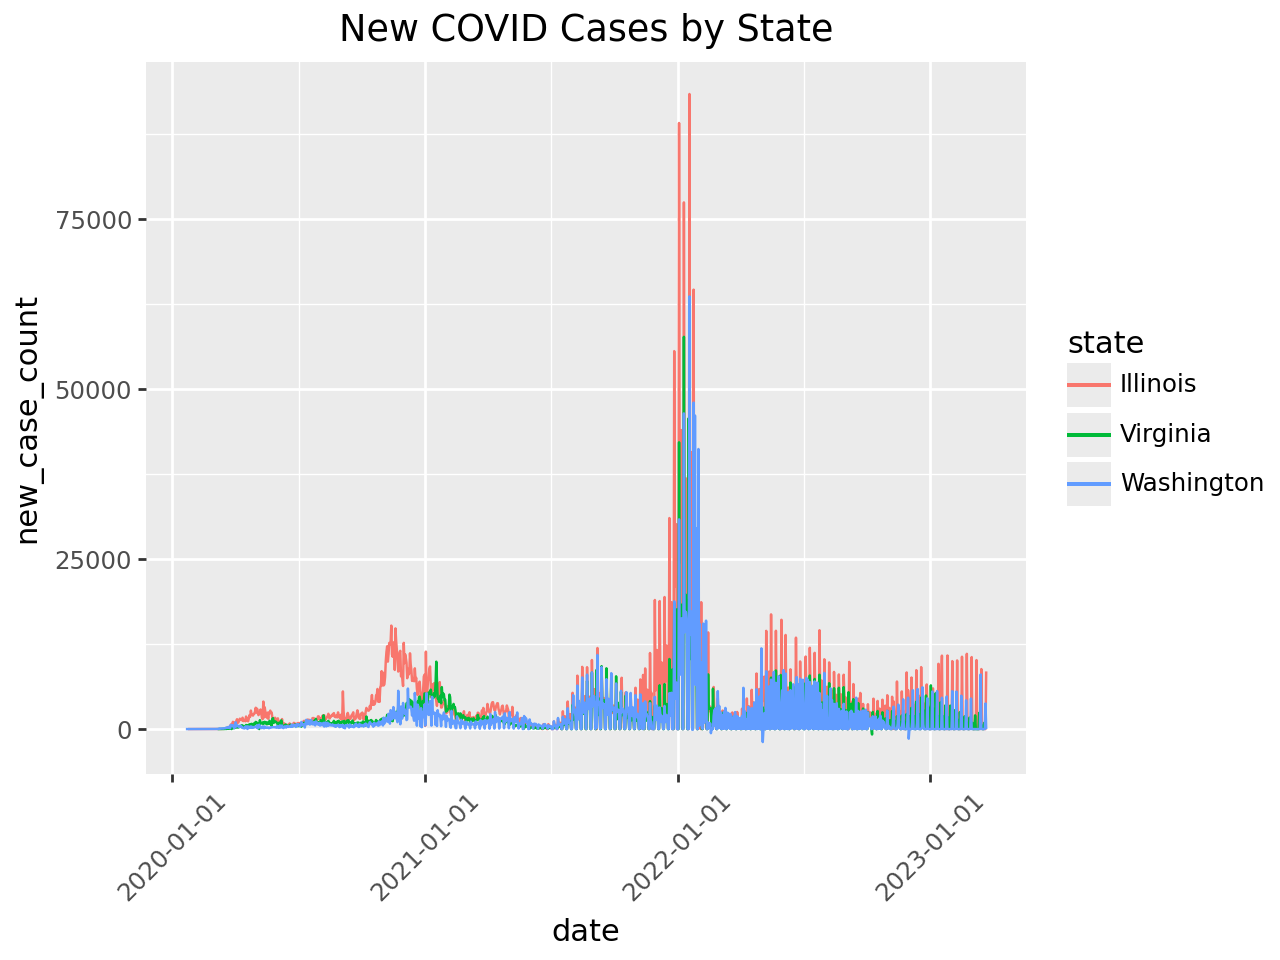

In [102]:
g = ggplot(plot_state, p9.aes(x='date', y='new_case_count', color='state'))+ p9.geom_line()+ p9.labs(title = 'New COVID Cases by State')+ p9.theme(axis_text_x=p9.element_text(angle=45))
g

In [103]:
 states2 = ["Tennessee", "Rhode Island", "Georgia"]

In [104]:
plot_state2 = pd.DataFrame()

In [105]:
for state in states2:
    state_df = new_case_count(coviddata[coviddata['state']==state])
    plot_state2 = pd.concat([plot_state2, state_df], ignore_index = True)

C:\Users\carol\AppData\Local\Temp\ipykernel_18716\2382091534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\carol\AppData\Local\Temp\ipykernel_18716\2382091534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
C:\Users\carol\AppData\Local\Temp\ipykernel_18716\2382091534.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

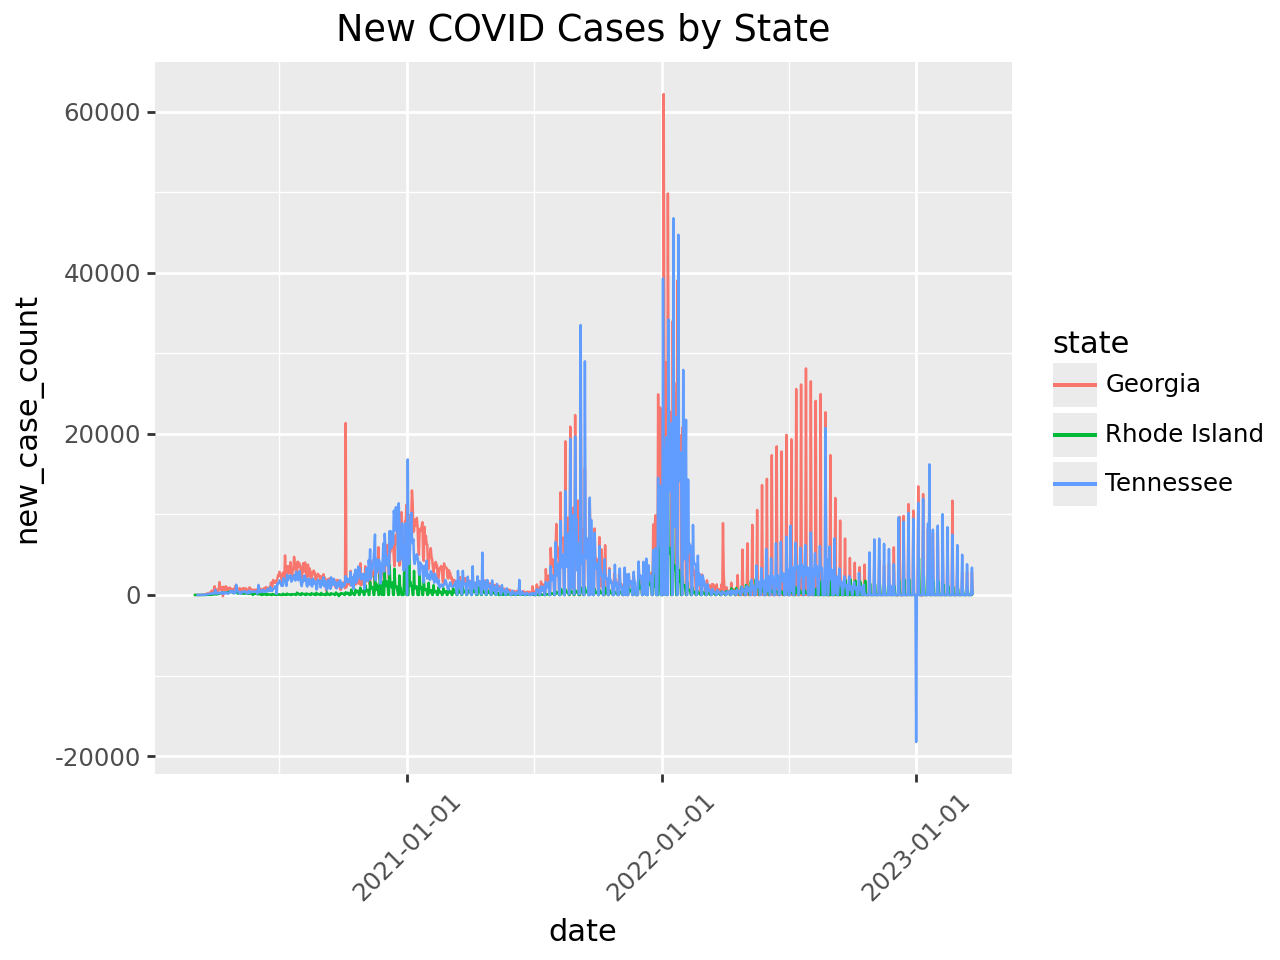

In [106]:
h = ggplot(plot_state2, p9.aes(x='date', y='new_case_count', color='state'))+ p9.geom_line()+ p9.labs(title = 'New COVID Cases by State')+ p9.theme(axis_text_x=p9.element_text(angle=45))
h

In [107]:
h.save('images/states2_graphs.png')


c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: images/states2_graphs.png


In [108]:
g.save('state_graphs.png')

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: state_graphs.png


In [109]:
def date_of_peak(df, state):
    data2 = new_case_count(df)
    data3 = data2[data2["state"]==state]
    max_case_count = data3["new_case_count"].idxmax()
    max_case_row = data3.loc[max_case_count,"date"]
    return max_case_row

In [110]:
date_of_peak(coviddata, "Georgia")

Timestamp('2022-01-04 00:00:00')

In [111]:
date_of_peak(coviddata, "Tennessee")

Timestamp('2022-01-18 00:00:00')

In [112]:
 def compare(df, state1, state2):
    peak_date1 = date_of_peak(df, state1)
    peak_date2 = date_of_peak(df, state2)
    delta = abs((peak_date1 - peak_date2).days)
    if peak_date1 > peak_date2:
        earlier_date = peak_date2
        earlier_state = state2
        later_date = peak_date1
        later_state = state1
        return(f"{state2} had its peak first and the peak was {delta} days apart")
    elif peak_date1 < peak_date2:
        earlier_date = peak_date1
        earlier_state = state1
        later_date = peak_date2
        later_state = state2
        return(f"{state1} had its peak first and the peak was {delta} days apart")
    elif peak_date1 == peak_date2:
        return(f"{state2} and {state1} had its peak on the same day")

In [114]:
compare(coviddata, "Tennessee", "Georgia")

'Georgia had its peak first and the peak was 14 days apart'

In [ ]:
compare(coviddata, "Florida", "Wyoming")

'Florida had its peak first and the peak was 14 days apart'

In [ ]:
compare(coviddata, "Tennessee", "Washington")

'Washington and Tennessee had its peak on the same day'

In [ ]:
florida = coviddata[coviddata['state']=='Florida']

In [ ]:
florida

,date,state,fips,cases,deaths,new_case_count
242,2020-03-01,Florida,12,2,0,0.0
255,2020-03-02,Florida,12,2,0,0.0
270,2020-03-03,Florida,12,3,0,1.0
286,2020-03-04,Florida,12,3,0,0.0
304,2020-03-05,Florida,12,4,0,1.0
...,...,...,...,...,...,...
61672,2023-03-19,Florida,12,7542869,87141,0.0
61728,2023-03-20,Florida,12,7542869,87141,0.0
61784,2023-03-21,Florida,12,7542869,87141,0.0
61840,2023-03-22,Florida,12,7542869,87141,0.0


In [ ]:
florida.describe()

,date,fips,cases,deaths,new_case_count
count,1118,1118.0,1.118000e+03,1118.000000,1118.000000
mean,2021-09-10 12:00:00,12.0,3.635996e+06,47132.761181,6746.750447
min,2020-03-01 00:00:00,12.0,2.000000e+00,0.000000,-40527.000000
25%,2020-12-05 06:00:00,12.0,1.051739e+06,19106.250000,0.000000
50%,2021-09-10 12:00:00,12.0,3.413662e+06,48772.000000,2836.500000
75%,2022-06-16 18:00:00,12.0,6.342659e+06,75093.750000,8269.250000
max,2023-03-23 00:00:00,12.0,7.542869e+06,87141.000000,193786.000000
std,NaN,0.0,2.660093e+06,29484.969861,13030.208176


In [ ]:
g = ggplot(florida, p9.aes(x='date', y='new_case_count', color='state'))+ p9.geom_line()+ p9.labs(title = 'New COVID Cases by State')+ p9.theme(axis_text_x=p9.element_text(angle=45))

In [ ]:
g.save('florida.png')

c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\carol\anaconda3\Lib\site-packages\plotnine\ggplot.py:631: PlotnineWarning: Filename: florida.png
